In [13]:
import pandas as pd
from pathlib import Path
import os
import time
import numpy as np
from functools import reduce
import csv
from typing import Union
import akshare as ak

In [14]:
os.chdir('/Users/liminglin/我的云端硬盘 (liminglin1998@gmail.com)/Sciences Po/Thesis/Data')
print("Current Directory:", os.getcwd())

Current Directory: /Users/liminglin/我的云端硬盘 (liminglin1998@gmail.com)/Sciences Po/Thesis/Data


# Montly GDP with Stock and Watson (2010) Methods

## Consumption

In [15]:
consump_df = pd.read_csv(
    "Social Consumption Retail Sales.csv",
    encoding="gbk",
    sep=",",
    header=2,      # use the 3rd row as the column names (dates)
    index_col=0,   # use the first column as the row labels (variables)
    engine="python",
)
consump_df = consump_df.iloc[:2, :].copy()

consump_df= consump_df.T.rename_axis("date").reset_index()

# 2) clean date text like "2026年2月" -> "2026-02"
consump_df["date"] = pd.to_datetime(consump_df["date"], format="%Y年%m月", errors="coerce")

consump_df.columns = ["date", "current consumption", "cumulative consumption"]

# Feb cumulative by year
year = consump_df["date"].dt.year
month = consump_df["date"].dt.month
feb_cum_by_year = consump_df.loc[month.eq(2)].set_index(year[month.eq(2)])["cumulative consumption"]

# fill Jan and Feb current = (Feb cumulative / 2)
for m in [1, 2]:
    mask = month.eq(m) & consump_df["current consumption"].isna()   # only fill missing
    consump_df.loc[mask, "current consumption"] = year[mask].map(feb_cum_by_year) / 2

## Trade

In [16]:
trade_df = pd.read_csv(
    "Export-Import.csv",
    encoding="gbk",
    sep=",",
    header=2,      # use the 3rd row as the column names (dates)
    index_col=0,   # use the first column as the row labels (variables)
    engine="python",
)

trade_df = trade_df.iloc[[12], :].copy()

trade_df = trade_df.T.rename_axis("date").reset_index()
# 2) clean date text like "2026年2月" -> "2026-02"
trade_df["date"] = pd.to_datetime(trade_df["date"], format="%Y年%m月", errors="coerce")

trade_df.columns = ["date", "trade balance"]

In [17]:
spot_df = pd.read_excel("CNYUSD_Spot_Rate.xlsx")
spot_df = spot_df[["指标名称", "CFETS:即期汇率:美元兑人民币"]].rename(columns={"指标名称": "date", "CFETS:即期汇率:美元兑人民币": "CNYUSDSpot"})
# Remove the notes rows
spot_df = spot_df.iloc[4:-2]


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


In [18]:
spot_df['date'] = pd.to_datetime(spot_df['date'])
spot_df = spot_df[spot_df['date'].dt.year >= 2000]
spot_df['CNYUSDSpot'] = pd.to_numeric(spot_df['CNYUSDSpot'], errors='coerce')
# collapse to monthly by taking the mean of all daily values in the month
spot_df = spot_df.groupby(spot_df['date'].dt.to_period('M'))['CNYUSDSpot'].mean().reset_index()
spot_df['date'] = spot_df['date'].dt.to_timestamp()  # convert back to datetime for merging


In [19]:
# Convert trade balance: USD thousands → RMB thousand millions (亿)
# CNYUSDSpot: RMB per 1 USD  →  trade_balance (USD thousands) × rate = RMB thousands
# RMB thousands ÷ 1,000,000 = RMB thousand millions
trade_df = trade_df.merge(spot_df[["date", "CNYUSDSpot"]], on="date", how="left")
trade_df["trade balance"] = (
    pd.to_numeric(trade_df["trade balance"], errors="coerce")
    * trade_df["CNYUSDSpot"]
    / 1_000_000
)
trade_df = trade_df.drop(columns=["CNYUSDSpot"])


## Fixed Asset Investment

In [20]:
fai_df = pd.read_csv(
    "Fixed Asset Investment.csv",
    encoding="gbk",
    sep=",",
    header=2,      # use the 3rd row as the column names (dates)
    index_col=0,   # use the first column as the row labels (variables)
    engine="python",
)
fai_df = fai_df.iloc[[0], :].copy()

fai_df = fai_df.T.rename_axis("date").reset_index()
# 2) clean date text like "2026年2月" -> "2026-02"
fai_df["date"] = pd.to_datetime(fai_df["date"], format="%Y年%m月", errors="coerce")

fai_df.columns = ["date", "fai growth"]


In [21]:
urbanfai_df = ak.macro_china_gdzctz()

urbanfai_df["月份"] = pd.to_datetime(urbanfai_df["月份"], format="%Y年%m月份", errors="coerce")

years = sorted(
    y for y in urbanfai_df["月份"].dt.year.dropna().astype(int).unique()
    if y >= 2000
)

jan_dates = pd.to_datetime([f"{y}-01-01" for y in years])
missing_jan = jan_dates[~jan_dates.isin(urbanfai_df["月份"].values)]

if len(missing_jan) > 0:
    jan_rows = pd.DataFrame({"月份": missing_jan})
    urbanfai_df = pd.concat([urbanfai_df, jan_rows], ignore_index=True)
    urbanfai_df = urbanfai_df.sort_values("月份").reset_index(drop=True)

urbanfai_df = urbanfai_df[["月份", "当月", "自年初累计"]].rename(columns={"月份": "date", "当月": "current", "自年初累计": "cumulative"})

# Feb cumulative by year
year = urbanfai_df["date"].dt.year
month = urbanfai_df["date"].dt.month
feb_cum_by_year = urbanfai_df.loc[month.eq(2)].set_index(year[month.eq(2)])["cumulative"]

# fill Jan and Feb current = (Feb cumulative / 2)
for m in [1, 2]:
    mask = month.eq(m) & urbanfai_df["current"].isna()   # only fill missing
    urbanfai_df.loc[mask, "current"] = year[mask].map(feb_cum_by_year) / 2


In [22]:
proxyfai_df = fai_df.merge(urbanfai_df[["date", "current", "cumulative"]], on="date", how="outer").sort_values("date").reset_index(drop=True)

In [23]:

# ── Rebuild proxyfai_df with guaranteed proper DatetimeIndex ───────────────────
_fai = fai_df[['date', 'fai growth']].copy()
_fai['date'] = pd.to_datetime(_fai['date'], errors='coerce')

_urb = urbanfai_df[['date', 'current', 'cumulative']].copy()
_urb['date'] = pd.to_datetime(_urb['date'], errors='coerce')
_urb['cumulative'] = pd.to_numeric(_urb['cumulative'], errors='coerce')
_urb['current']    = pd.to_numeric(_urb['current'],    errors='coerce')

proxyfai_df = (
    _fai.merge(_urb, on='date', how='outer')
    .sort_values('date')
    .set_index('date')
)
proxyfai_df['fai growth'] = pd.to_numeric(proxyfai_df['fai growth'], errors='coerce')

print("Index sample:", proxyfai_df.index[:3].tolist())
print("Cumulative non-null:", proxyfai_df['cumulative'].notna().sum())

# ── Step 1: Find anchor year — earliest year >= 2008 with real cumulative data ─
valid_mask = (
    proxyfai_df['cumulative'].notna() &
    (proxyfai_df['cumulative'] > 0) &
    (proxyfai_df.index.year >= 2008)
)
if not valid_mask.any():
    raise ValueError("No valid cumulative data found in 2008 or later")
anchor_year = int(proxyfai_df.index[valid_mask].year.min())
print(f"Anchor year: {anchor_year}")

# ── Step 2: Backcast cumulative month-by-month from anchor_year back to 2000 ──
# Skip January (NBS doesn't report Jan separately); leave it NaN.
# Formula: cum[year, m] = cum[year+1, m] / (1 + fai_growth[year+1, m] / 100)
for year in range(anchor_year - 1, 1999, -1):
    for month in range(2, 13):
        date_curr = pd.Timestamp(year=year,     month=month, day=1)
        date_next = pd.Timestamp(year=year + 1, month=month, day=1)

        if date_curr not in proxyfai_df.index or date_next not in proxyfai_df.index:
            continue

        cum_next    = proxyfai_df.loc[date_next, 'cumulative']
        growth_next = proxyfai_df.loc[date_next, 'fai growth']

        if pd.notna(cum_next) and cum_next > 0 and pd.notna(growth_next):
            proxyfai_df.loc[date_curr, 'cumulative'] = cum_next / (1 + growth_next / 100)

# ── Step 3: Derive current values from cumulative ─────────────────────────────
for year in proxyfai_df.index.year.unique():
    for month in range(1, 13):
        date = pd.Timestamp(year=int(year), month=month, day=1)
        if date not in proxyfai_df.index:
            continue

        if month == 1:
            pass  # filled when Feb is processed below

        elif month == 2:
            feb_cum = proxyfai_df.loc[date, 'cumulative']
            if pd.notna(feb_cum):
                proxyfai_df.loc[date, 'current'] = feb_cum / 2
                jan = pd.Timestamp(year=int(year), month=1, day=1)
                if jan in proxyfai_df.index:
                    proxyfai_df.loc[jan, 'current'] = feb_cum / 2

        else:
            if pd.isna(proxyfai_df.loc[date, 'current']):
                prev = pd.Timestamp(year=int(year), month=month - 1, day=1)
                if prev in proxyfai_df.index:
                    cum_this = proxyfai_df.loc[date, 'cumulative']
                    cum_prev = proxyfai_df.loc[prev, 'cumulative']
                    if pd.notna(cum_this) and pd.notna(cum_prev):
                        proxyfai_df.loc[date, 'current'] = cum_this - cum_prev

print("\nResult (2000–2010):")
print(proxyfai_df.loc['2000':'2010', ['fai growth', 'cumulative', 'current']])


Index sample: [Timestamp('2000-01-01 00:00:00'), Timestamp('2000-02-01 00:00:00'), Timestamp('2000-03-01 00:00:00')]
Cumulative non-null: 199
Anchor year: 2008

Result (2000–2010):
            fai growth     cumulative       current
date                                               
2000-01-01         NaN            NaN    568.952440
2000-02-01         8.6    1137.904880    568.952440
2000-03-01         8.5    2528.888169   1390.983289
2000-04-01         9.3    4006.294087   1477.405917
2000-05-01         9.5    5886.383938   1880.089851
...                ...            ...           ...
2010-08-01        24.8  140997.740000  21131.500000
2010-09-01        24.5  165869.580000  24871.830000
2010-10-01        24.4  187556.100000  21686.530000
2010-11-01        24.9  210697.830000  23141.720000
2010-12-01        24.5  241414.930000  30717.100000

[132 rows x 3 columns]


In [24]:
proxyfai_df.columns = ["fai_growth", "proxy_fai", "proxy_cumulative_fai"]

## Government Spending

In [25]:
gov_df = pd.read_csv(
    "NationalGovSpend.csv",
    encoding="gbk",
    sep=",",
    header=2,      # use the 3rd row as the column names (dates)
    index_col=0,   # use the first column as the row labels (variables)
    engine="python",
)
gov_df = gov_df.iloc[[0], :].copy()

gov_df = gov_df.T.rename_axis("date").reset_index()
# 2) clean date text like "2026年2月" -> "2026-02"
gov_df["date"] = pd.to_datetime(gov_df["date"], format="%Y年%m月", errors="coerce")

gov_df.columns = ["date", "gov_spend_ytd"]

In [26]:
# generate and calculate current values for gov spend
gov_df = gov_df.sort_values("date").reset_index(drop=True)
gov_df["gov_spend_ytd"] = pd.to_numeric(gov_df["gov_spend_ytd"], errors="coerce")

year  = gov_df["date"].dt.year
month = gov_df["date"].dt.month

# Feb cumulative by year
feb_cum_by_year = gov_df.loc[month.eq(2)].set_index(year[month.eq(2)])["gov_spend_ytd"]

gov_df["gov_spend_current"] = np.nan

# Jan and Feb: each = Feb cumulative / 2
for m in [1, 2]:
    mask = month.eq(m)
    gov_df.loc[mask, "gov_spend_current"] = year[mask].map(feb_cum_by_year) / 2

# Mar–Dec: current = cumulative_t - cumulative_{t-1}
# Use date-based lookup to avoid index-gap issues
ytd_by_date = gov_df.set_index("date")["gov_spend_ytd"]
mar_plus    = month.gt(2)
prev_dates  = gov_df.loc[mar_plus, "date"] - pd.DateOffset(months=1)
gov_df.loc[mar_plus, "gov_spend_current"] = (
    gov_df.loc[mar_plus, "gov_spend_ytd"].values
    - prev_dates.map(ytd_by_date).values
)

print(gov_df[["date", "gov_spend_ytd", "gov_spend_current"]])

          date  gov_spend_ytd  gov_spend_current
0   2000-01-01            NaN             748.85
1   2000-02-01         1497.7             748.85
2   2000-03-01         2376.4             878.70
3   2000-04-01         3463.8            1087.40
4   2000-05-01         4485.9            1022.10
..         ...            ...                ...
309 2025-10-01       225825.0           17761.00
310 2025-11-01       248538.0           22713.00
311 2025-12-01       287395.0           38857.00
312 2026-01-01            NaN                NaN
313 2026-02-01            NaN                NaN

[314 rows x 3 columns]


In [27]:
annualgov_df = pd.read_csv(
    "AnnualGovSpend.csv",
    encoding="gbk",
    sep=",",
    header=2,      # use the 3rd row as the column names (dates)
    index_col=0,   # use the first column as the row labels (variables)
    engine="python",
)
annualgov_df = annualgov_df.iloc[[0], :].copy()

annualgov_df = annualgov_df.T.rename_axis("date").reset_index()
# 2) clean date text like "2026年2月" -> "2026-02"
annualgov_df["date"] = pd.to_datetime(annualgov_df["date"], format="%Y年", errors="coerce")

annualgov_df.columns = ["date", "gov_spend_annual"]

In [28]:
# Fill missing December YTD and current values (2000–2009) from annual totals
annualgov_df["gov_spend_annual"] = pd.to_numeric(annualgov_df["gov_spend_annual"], errors="coerce")

# Build year → annual total lookup
annual_by_year = annualgov_df.set_index(annualgov_df["date"].dt.year)["gov_spend_annual"]

# Re-build date-based YTD lookup (needed to look up November after filling December)
ytd_by_date = gov_df.set_index("date")["gov_spend_ytd"]

dec_mask = (gov_df["date"].dt.month == 12) & (gov_df["date"].dt.year.between(2000, 2009))

for i in gov_df.index[dec_mask]:
    yr       = gov_df.loc[i, "date"].year
    annual   = annual_by_year.get(yr, np.nan)
    nov_date = pd.Timestamp(year=yr, month=11, day=1)
    nov_ytd  = ytd_by_date.get(nov_date, np.nan)

    if pd.notna(annual):
        gov_df.loc[i, "gov_spend_ytd"]     = annual
        gov_df.loc[i, "gov_spend_current"] = annual - nov_ytd if pd.notna(nov_ytd) else np.nan

print(gov_df.loc[gov_df["date"].dt.year.between(2000, 2010) & (gov_df["date"].dt.month.isin([10, 11, 12])),
                 ["date", "gov_spend_ytd", "gov_spend_current"]])

          date  gov_spend_ytd  gov_spend_current
9   2000-10-01       10533.70            1080.90
10  2000-11-01       11909.30            1375.60
11  2000-12-01       13395.23            1485.93
21  2001-10-01       12703.10            1223.50
22  2001-11-01       14504.50            1801.40
23  2001-12-01       16386.04            1881.54
33  2002-10-01       15011.40            1513.80
34  2002-11-01       16911.40            1900.00
35  2002-12-01       18903.64            1992.24
45  2003-10-01       16947.90            1683.00
46  2003-11-01       18932.00            1984.10
47  2003-12-01       21715.25            2783.25
57  2004-10-01       19061.90            1917.30
58  2004-11-01       21593.70            2531.80
59  2004-12-01       26396.47            4802.77
69  2005-10-01       22137.90            2188.00
70  2005-11-01       25326.30            3188.40
71  2005-12-01       31649.29            6322.99
81  2006-10-01       25827.50            2670.50
82  2006-11-01      

## CPI

In [29]:
cpi2015_df = pd.read_csv(
    "cpi2015.csv",
    encoding="gbk",
    sep=",",
    header=2,      # use the 3rd row as the column names (dates)
    index_col=0,   # use the first column as the row labels (variables)
    engine="python",
)
cpi2015_df = cpi2015_df.iloc[[0], :].copy()

cpi2015_df = cpi2015_df.T.rename_axis("date").reset_index()
# 2) clean date text like "2026年2月" -> "2026-02"
cpi2015_df["date"] = pd.to_datetime(cpi2015_df["date"], format="%Y年%m月", errors="coerce")

cpi2015_df.columns = ["date", "cpi"]

cpi2015_df["cpi"] = cpi2015_df["cpi"] - 100 


In [30]:
cpi2020_df = pd.read_csv(
    "cpi2016-2020.csv",
    encoding="gbk",
    sep=",",
    header=2,      # use the 3rd row as the column names (dates)
    index_col=0,   # use the first column as the row labels (variables)
    engine="python",
)
cpi2020_df = cpi2020_df.iloc[[0], :].copy()

cpi2020_df = cpi2020_df.T.rename_axis("date").reset_index()
# 2) clean date text like "2026年2月" -> "2026-02"
cpi2020_df["date"] = pd.to_datetime(cpi2020_df["date"], format="%Y年%m月", errors="coerce")

cpi2020_df.columns = ["date", "cpi"]

cpi2020_df["cpi"] = cpi2020_df["cpi"] - 100 


In [31]:
cpi2025_df = pd.read_csv(
    "cpi2021-2025.csv",
    encoding="gbk",
    sep=",",
    header=2,      # use the 3rd row as the column names (dates)
    index_col=0,   # use the first column as the row labels (variables)
    engine="python",
)
cpi2025_df = cpi2025_df.iloc[[0], :].copy()

cpi2025_df = cpi2025_df.T.rename_axis("date").reset_index()
# 2) clean date text like "2026年2月" -> "2026-02"
cpi2025_df["date"] = pd.to_datetime(cpi2025_df["date"], format="%Y年%m月", errors="coerce")

cpi2025_df.columns = ["date", "cpi"]

cpi2025_df["cpi"] = cpi2025_df["cpi"] - 100 


In [32]:
cpi_df = (
    pd.concat([cpi2015_df, cpi2020_df, cpi2025_df], ignore_index=True)
    .drop_duplicates(subset="date")
    .sort_values("date")
    .reset_index(drop=True)
)

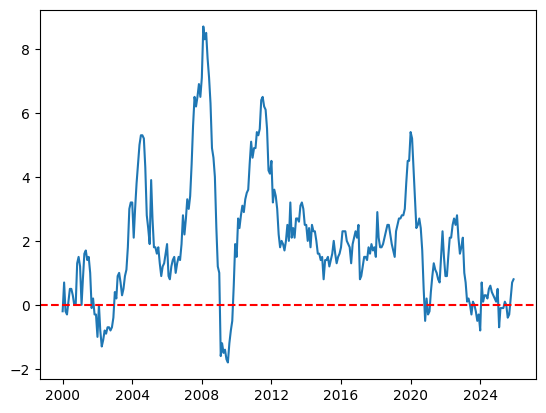

In [33]:
# plot cpi
import matplotlib.pyplot as plt
plt.plot(cpi_df["date"], cpi_df["cpi"])
#add y=0 line in red
plt.axhline(0, color='red', linestyle='--')
plt.show()

In [34]:
# list cpi from 2020 to 2025
print(cpi_df[cpi_df["date"].dt.year >= 2022][["date", "cpi"]])

          date  cpi
264 2022-01-01  0.9
265 2022-02-01  0.9
266 2022-03-01  1.5
267 2022-04-01  2.1
268 2022-05-01  2.1
269 2022-06-01  2.5
270 2022-07-01  2.7
271 2022-08-01  2.5
272 2022-09-01  2.8
273 2022-10-01  2.1
274 2022-11-01  1.6
275 2022-12-01  1.8
276 2023-01-01  2.1
277 2023-02-01  1.0
278 2023-03-01  0.7
279 2023-04-01  0.1
280 2023-05-01  0.2
281 2023-06-01  0.0
282 2023-07-01 -0.3
283 2023-08-01  0.1
284 2023-09-01  0.0
285 2023-10-01 -0.2
286 2023-11-01 -0.5
287 2023-12-01 -0.3
288 2024-01-01 -0.8
289 2024-02-01  0.7
290 2024-03-01  0.1
291 2024-04-01  0.3
292 2024-05-01  0.3
293 2024-06-01  0.2
294 2024-07-01  0.5
295 2024-08-01  0.6
296 2024-09-01  0.4
297 2024-10-01  0.3
298 2024-11-01  0.2
299 2024-12-01  0.1
300 2025-01-01  0.5
301 2025-02-01 -0.7
302 2025-03-01 -0.1
303 2025-04-01 -0.1
304 2025-05-01 -0.1
305 2025-06-01  0.1
306 2025-07-01  0.0
307 2025-08-01 -0.4
308 2025-09-01 -0.3
309 2025-10-01  0.2
310 2025-11-01  0.7
311 2025-12-01  0.8


## Real GDP

In [35]:
gdp_df = pd.read_excel("China_RealGDP.xlsx")

gdp_df = gdp_df[["指标名称", "中国:GDP:不变价:当季值","中国:GDP:不变价:当季同比"]].rename(columns={"指标名称": "date", "中国:GDP:不变价:当季值" : "realgdp","中国:GDP:不变价:当季同比": "realgdpgrowth"})

# Remove the notes rows
gdp_df = gdp_df.iloc[4:-2]

gdp_df['date'] = pd.to_datetime(gdp_df['date']).dt.to_period('Q')

gdp_df = gdp_df[gdp_df['date'].dt.year >= 2000]
gdp_df['realgdp'] = pd.to_numeric(gdp_df['realgdp'], errors='coerce')
gdp_df['realgdpgrowth'] = pd.to_numeric(gdp_df['realgdpgrowth'], errors='coerce')

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


In [36]:
# Backcast realgdp using YoY growth: realgdp[t] = realgdp[t+4] / (1 + realgdpgrowth[t+4] / 100)
# Anchor: actual realgdp from 2007 Q4; backcast from 2006 Q4 back to 2000 Q1

gdp_df = gdp_df.sort_values('date').set_index('date')

for q in sorted(gdp_df.index, reverse=True):
    if pd.isna(gdp_df.loc[q, 'realgdp']):
        q_plus4 = q + 4
        if q_plus4 in gdp_df.index:
            gdp_next    = gdp_df.loc[q_plus4, 'realgdp']
            growth_next = gdp_df.loc[q_plus4, 'realgdpgrowth']
            if pd.notna(gdp_next) and pd.notna(growth_next):
                gdp_df.loc[q, 'realgdp'] = gdp_next / (1 + growth_next / 100)

gdp_df = gdp_df.reset_index()

## Real Effective Exchange Rate

In [37]:
neer_df = pd.read_csv("RBCNBIS_PC1.csv", encoding="gbk", sep=",", header=0, index_col=0, engine="python")
neer_df = neer_df.reset_index().rename(columns={"observation_date": "date", "RBCNBIS_PC1": "neer_yoy"})
neer_df['date'] = pd.to_datetime(neer_df['date'], errors="coerce")

## Combine Monthly Data

In [38]:
# In your notebook, BEFORE calling prepare_and_run:

# Start from the latest quarter and work backwards using NBS growth rates
gdp_df = gdp_df.sort_values("date").reset_index(drop=True)

# Use the last available quarter as anchor
anchor_idx = gdp_df["realgdp"].last_valid_index()
chain_gdp = gdp_df["realgdp"].copy()

# Go backwards: Q[t] = Q[t+4] / (1 + growth[t+4]/100)
for i in range(anchor_idx - 4, -1, -1):
    growth_forward = gdp_df.loc[i + 4, "realgdpgrowth"]
    level_forward = chain_gdp.iloc[i + 4]
    if pd.notna(growth_forward) and pd.notna(level_forward):
        chain_gdp.iloc[i] = level_forward / (1 + growth_forward / 100)

gdp_df["realgdp_chained"] = chain_gdp

# Verify: implied YoY should now match NBS reported growth
gdp_df["implied_yoy"] = gdp_df["realgdp_chained"].pct_change(4) * 100
print(gdp_df[["date", "realgdp", "realgdp_chained", "realgdpgrowth", "implied_yoy"]]
      .query("date.dt.year.between(2009, 2012)"))

      date   realgdp  realgdp_chained  realgdpgrowth  implied_yoy
36  2009Q1   64349.4    105257.472405            6.4          6.4
37  2009Q2   72031.5    116444.897927            8.2          8.2
38  2009Q3   74923.3    124808.107601           10.6         10.6
39  2009Q4   81767.9    137107.233165           11.9         11.9
40  2010Q1   72173.5    118098.884038           12.2         12.2
41  2010Q2   79733.2    128904.502005           10.7         10.7
42  2010Q3   82315.2    137164.110253            9.9          9.9
43  2010Q4   89891.3    150680.849248            9.9          9.9
44  2011Q1  100490.0    130026.871326           10.1         10.1
45  2011Q2  112089.8    141666.047703            9.9          9.9
46  2011Q3  117167.9    149920.372507            9.3          9.3
47  2011Q4  129175.6    163790.083133            8.7          8.7
48  2012Q1  108621.0    140559.047903            8.1          8.1
49  2012Q2  120674.3    152574.333376            7.7          7.7
50  2012Q3

In [39]:
# combine all dataframes into one
gdp_monthly_df = reduce(
    lambda left, right: pd.merge(left, right, on="date", how="outer"),
    [
        cpi_df[["date", "cpi"]],
        gov_df[["date", "gov_spend_current"]],
        proxyfai_df[["proxy_fai"]].reset_index(),
        trade_df[["date", "trade balance"]],
        consump_df[["date", "current consumption"]],
        spot_df[["date", "CNYUSDSpot"]],
        neer_df[["date", "neer_yoy"]],
    ]
).sort_values("date").reset_index(drop=True)

In [40]:
# After building realgdp_chained in gdp_df, map it back to gdp_monthly_df
# (same way you originally mapped realgdp)

gdp_q = gdp_df[['date', 'realgdp_chained']].copy()
gdp_q['date'] = gdp_q['date'].dt.to_timestamp(how='end').dt.to_period('M').dt.to_timestamp()

# Drop old realgdp column and replace
gdp_monthly_df = gdp_monthly_df.drop(columns=["realgdp"], errors="ignore")
gdp_monthly_df = gdp_monthly_df.merge(
    gdp_q.rename(columns={"realgdp_chained": "realgdp"}), 
    on="date", how="left"
)

In [41]:
gdp_monthly_df = gdp_monthly_df[gdp_monthly_df["date"] < "2026-01-01"].reset_index(drop=True)


## Stock & Watson (2010)

In [42]:
from stock_watson_distribute import prepare_and_run

gdp_monthly_df = prepare_and_run(gdp_monthly_df, break_year=None)


  Full sample
Sample: 2000-01 to 2025-12  (104 quarters, 312 months)
  Quarterly seasonal factors: [0.917 0.973 1.014 1.095]

Estimating monthly real GDP (seasonally adjusted)...
  β = [0.2041 0.1174 0.0056 0.0052 0.    ],  ρ = -0.4622,  σ = 0.002647

Adding-up check (first 5 quarters):
  Q1: quarterly = 42530.17, monthly sum = 42530.17, diff = 0.00000000
  Q2: quarterly = 46388.81, monthly sum = 46388.81, diff = 0.00000000
  Q3: quarterly = 50636.42, monthly sum = 50636.42, diff = -0.00000000
  Q4: quarterly = 56487.32, monthly sum = 56487.32, diff = 0.00000000
  Q5: quarterly = 46570.54, monthly sum = 46570.54, diff = -0.00000000


         date       realgdp  realgdp_monthly  realgdp_monthly_yoy
0  2000-01-01           NaN     14085.837939                  NaN
1  2000-02-01           NaN     14190.393003                  NaN
2  2000-03-01  42530.173377     14253.942435                  NaN
3  2000-04-01           NaN     15296.557608                  NaN
4  2000-05-01           NaN     15601.808308                  NaN
5  2000-06-01  46388.813863     15490.447948                  NaN
6  2000-07-01           NaN     16833.221614                  NaN
7  2000-08-01           NaN     16876.118105                  NaN
8  2000-09-01  50636.421115     16927.081396                  NaN
9  2000-10-01           NaN     18532.790218                  NaN
10 2000-11-01           NaN     18475.636743                  NaN
11 2000-12-01  56487.315359     19478.888398                  NaN
12 2001-01-01           NaN     15579.403573            10.603314
13 2001-02-01           NaN     15439.733348             8.804128
14 2001-03

/var/folders/0f/mpgmxljn0vgdf8f9l1h__6r40000gn/T/ipykernel_31693/1454613554.py:23: UserWarning: Glyph 20159 (\N{CJK UNIFIED IDEOGRAPH-4EBF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/0f/mpgmxljn0vgdf8f9l1h__6r40000gn/T/ipykernel_31693/1454613554.py:23: UserWarning: Glyph 20803 (\N{CJK UNIFIED IDEOGRAPH-5143}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/liminglin/Library/Python/3.13/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20159 (\N{CJK UNIFIED IDEOGRAPH-4EBF}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/liminglin/Library/Python/3.13/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20803 (\N{CJK UNIFIED IDEOGRAPH-5143}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


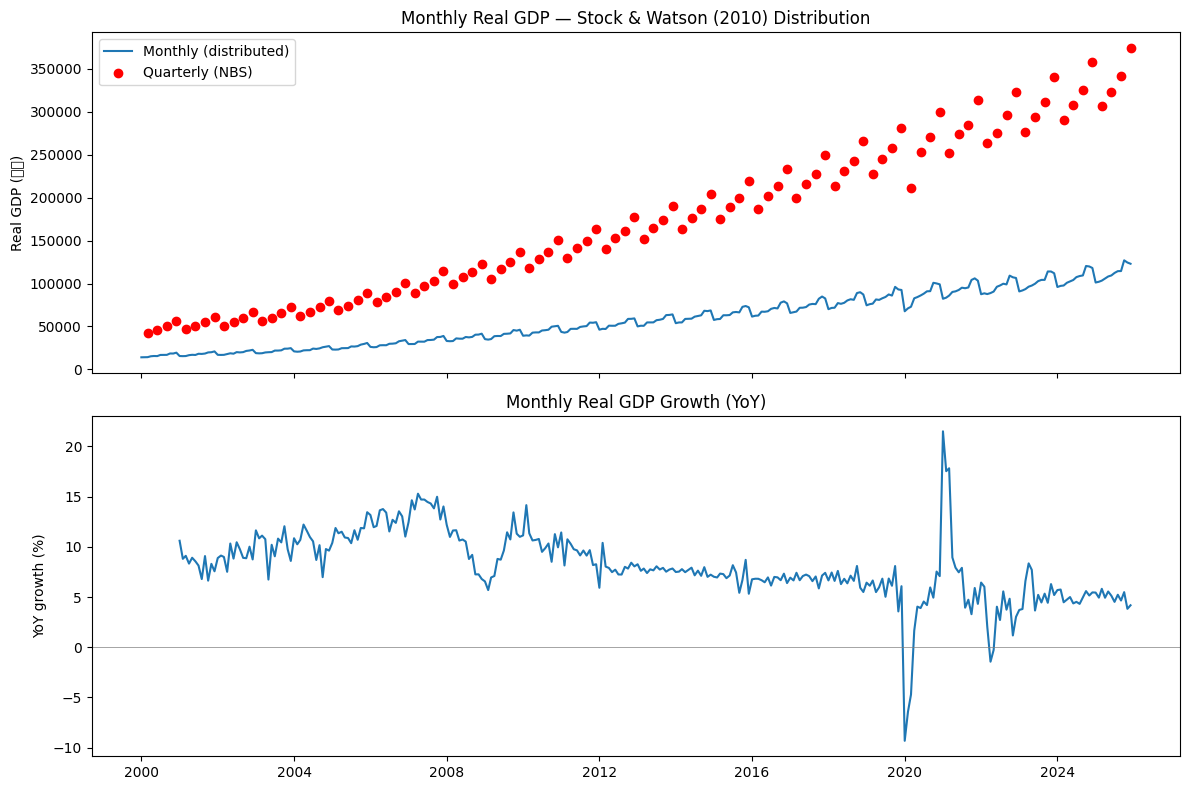

In [43]:
# Look at the monthly series
print(gdp_monthly_df[["date", "realgdp", "realgdp_monthly", "realgdp_monthly_yoy"]].dropna(subset=["realgdp_monthly"]).head(24))

# Quick plot
import matplotlib.pyplot as plt
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

ax = axes[0]
ax.plot(gdp_monthly_df["date"], gdp_monthly_df["realgdp_monthly"], label="Monthly (distributed)")
q_rows = gdp_monthly_df["realgdp"].notna()
ax.scatter(gdp_monthly_df.loc[q_rows, "date"], gdp_monthly_df.loc[q_rows, "realgdp"],
           color="red", zorder=5, label="Quarterly (NBS)")
ax.set_ylabel("Real GDP (亿元)")
ax.legend()
ax.set_title("Monthly Real GDP — Stock & Watson (2010) Distribution")

ax = axes[1]
ax.plot(gdp_monthly_df["date"], gdp_monthly_df["realgdp_monthly_yoy"])
ax.axhline(0, color="grey", linewidth=0.5)
ax.set_ylabel("YoY growth (%)")
ax.set_title("Monthly Real GDP Growth (YoY)")

plt.tight_layout()
plt.show()

# Narrative Shocks

## Market FR007

In [44]:
# 1. Create a list of years to loop through
years = range(2000, 2026) 
all_data = []

print("Starting download loop...")

for year in years:
    start_date = f"{year}0101"
    end_date = f"{year}1231"
    
    print(f"Fetching data for {year}...")
    
    try:
        # Fetch data for the specific year
        df = ak.repo_rate_hist(start_date=start_date, end_date=end_date)
        
        # Optional: Add a 'Year' column if you want to track it explicitly
        # df['Year'] = year 
        
        all_data.append(df)
        
        # Pause briefly to be polite to the server (prevents blocking)
        time.sleep(1) 
        
    except Exception as e:
        print(f"Error fetching data for {year}: {e}")
        # Continue to the next year even if one fails

# 2. Combine all years into one DataFrame
if all_data:
    full_repo_df = pd.concat(all_data, ignore_index=True)
    
    # 3. Clean duplicates (just in case) and Sort
    # The date column name might vary slightly; usually it is 'date' or '日期'
    # Check the column names if sort fails.
    if '日期' in full_repo_df.columns:
        full_repo_df.rename(columns={'日期': 'date'}, inplace=True)
        
    full_repo_df['date'] = pd.to_datetime(full_repo_df['date'])
    full_repo_df.sort_values('date', inplace=True)
    
    # 4. Filter for R007 specifically
    # The column for the rate might be '收盘' (Close) or similar.
    # Often the dataframe contains multiple repo types. 
    # If the output contains a "symbol" or "code" column, filter for "R-007" or similar.
    # (Inspect full_repo_df.head() to be sure of the column name for 7-day repo)

    print("Download Complete!")
    print(full_repo_df.head())
    print(f"Total rows: {len(full_repo_df)}")
    

else:
    print("No data fetched.")


full_repo_df['date'] = pd.to_datetime(full_repo_df['date'])
# Keep only FR007 and collapse to monthly mean
full_repo_df = (
    full_repo_df[["date", "FR007"]]
    .groupby(full_repo_df["date"].dt.to_period("M"))["FR007"]
    .mean()
    .reset_index()
)
full_repo_df["date"] = full_repo_df["date"].dt.to_timestamp()

Starting download loop...
Fetching data for 2000...
Fetching data for 2001...
Fetching data for 2002...
Fetching data for 2003...
Error fetching data for 2003: Expecting value: line 1 column 1 (char 0)
Fetching data for 2004...
Fetching data for 2005...
Fetching data for 2006...
Fetching data for 2007...
Fetching data for 2008...
Fetching data for 2009...
Fetching data for 2010...
Fetching data for 2011...
Fetching data for 2012...
Fetching data for 2013...
Fetching data for 2014...
Fetching data for 2015...
Fetching data for 2016...
Fetching data for 2017...
Fetching data for 2018...
Fetching data for 2019...
Fetching data for 2020...
Fetching data for 2021...
Fetching data for 2022...
Fetching data for 2023...
Fetching data for 2024...
Fetching data for 2025...
Download Complete!
        date  FR001  FR007  FR014  FDR001  FDR007  FDR014
0 2000-01-04    NaN   2.57    NaN     NaN     NaN     NaN
1 2000-01-05    NaN   2.56    NaN     NaN     NaN     NaN
2 2000-01-06    NaN   2.57    NaN

## Official R007

In [45]:
omo_df = pd.read_excel("CMPI.xlsx", sheet_name="逆回购利率", header=1, index_col=False)
omo_df = omo_df[["时间", "7天"]].rename(columns={"时间": "date", "7天": "omo7d"})
omo_df["date"] = pd.to_datetime(omo_df["date"], errors="coerce")
omo_df["omo7d"] = pd.to_numeric(omo_df["omo7d"], errors="coerce")
omo_df = omo_df.sort_values("date").ffill()
omo_df = omo_df[omo_df["date"].dt.year >= 2000]

# Collapse to monthly mean (only announced months present at this point)
omo_df = (
    omo_df.groupby(omo_df["date"].dt.to_period("M"))["omo7d"]
    .mean()
    .reset_index()
)
omo_df["date"] = omo_df["date"].dt.to_timestamp()

# Reindex to full monthly range and forward fill missing months
full_months = pd.date_range(omo_df["date"].min(), omo_df["date"].max(), freq="MS")
omo_df = (
    omo_df.set_index("date")
    .reindex(full_months)
    .ffill()
    .rename_axis("date")
    .reset_index()
)

## Central Parity Rate

In [46]:
cpr_df = ak.currency_boc_sina(symbol="美元", start_date="20000101", end_date="20251231")
cpr_df = cpr_df[["日期", "央行中间价"]].rename(columns={"日期": "date", "央行中间价": "CNYUSDCPR"})
cpr_df['date'] = pd.to_datetime(cpr_df['date'])
cpr_df = cpr_df[cpr_df['date'].dt.year >= 2000]
cpr_df = (
    cpr_df.groupby(cpr_df["date"].dt.to_period("M"))["CNYUSDCPR"]
    .mean()
    .reset_index()
)
cpr_df['CNYUSDCPR'] = cpr_df['CNYUSDCPR'] / 100
cpr_df["date"] = cpr_df["date"].dt.to_timestamp()

## Industrial Output (Above designated size)

In [49]:
ip_df = pd.read_csv(
    "IP.csv",
    encoding="gbk",
    sep=",",
    header=2,      # use the 3rd row as the column names (dates)
    index_col=0,   # use the first column as the row labels (variables)
    engine="python",
)
ip_df = ip_df.iloc[:2, :].copy()

ip_df = ip_df.T.rename_axis("date").reset_index()
# 2) clean date text like "2026年2月" -> "2026-02"
ip_df["date"] = pd.to_datetime(ip_df["date"], format="%Y年%m月", errors="coerce")

ip_df.columns = ["date", "IP_yoy", "IP_cumulative"]

In [50]:
# Feb cumulative by year
year = ip_df["date"].dt.year
month = ip_df["date"].dt.month
feb_ip_cum_by_year = ip_df.loc[month.eq(2)].set_index(year[month.eq(2)])["IP_cumulative"]

# fill Jan and Feb current = Feb cumulative
for m in [1, 2]:
    mask = month.eq(m) & ip_df["IP_yoy"].isna()   # only fill missing
    ip_df.loc[mask, "IP_yoy"] = year[mask].map(feb_ip_cum_by_year)

## Combine the dataframe

In [74]:
# combine all dataframes into one_df 
romer_df = reduce(
    lambda left, right: pd.merge(left, right, on="date", how="outer"),
    [
        gdp_monthly_df[["date", "realgdp_monthly_yoy", "cpi", "CNYUSDSpot", "trade balance", "current consumption"]],
        full_repo_df[["date", "FR007"]],
        omo_df[["date", "omo7d"]],
        cpr_df[["date", "CNYUSDCPR"]],
        ip_df[["date", "IP_yoy"]],
        neer_df[["date", "neer_yoy"]],
    ]
).sort_values("date").reset_index(drop=True)

## Official GDP and CPI Target

In [75]:
# 1. Define the targets (Midpoints used for ranges)
# Source: Government Work Reports
china_gdp_targets = {
    2000: 7.0, 2001: 7.0, 2002: 7.0, 2003: 7.0, 2004: 7.0,
    2005: 8.0, 2006: 8.0, 2007: 8.0, 2008: 8.0, 2009: 8.0,
    2010: 8.0, 2011: 8.0, 2012: 7.5, 2013: 7.5, 2014: 7.5,
    2015: 7.0, 
    2016: 6.75, # Range 6.5-7.0 -> Midpoint 6.75
    2017: 6.5, 
    2018: 6.5, 
    2019: 6.25, # Range 6.0-6.5 -> Midpoint 6.25
    2020: 6.0, # No official target set Set to 6.0 for calculation
    2021: 6.0,  # "Above 6.0" -> Treated as 6.0 baseline
    2022: 5.5, 
    2023: 5.0,
    2024: 5.0,
    2025: 5.0
}

china_cpi_targets = {
    2000: 2.0, 2001: 1.5, 2002: 1.5, 2003: 1.0, 2004: 3.0,
    2005: 4.0, 2006: 3.0, 2007: 3.0, 2008: 4.8, 2009: 4.0,
    2010: 3.0, 2011: 4.0, 2012: 4.0, 2013: 3.5, 2014: 3.5,
    2015: 3.0, 2016: 3.0, 2017: 3.0, 2018: 3.0, 2019: 3.0,
    2020: 3.5, 2021: 3.0, 2022: 3.0, 2023: 3.0, 2024: 3.0,
    2025: 2.0
}

years = romer_df['date'].dt.year
romer_df['target_gdp'] = years.map(china_gdp_targets)
romer_df['target_cpi'] = years.map(china_cpi_targets)

## Save the data

In [76]:
# save to CSV for use in the dashboard
romer_df.to_csv("romer_china_data.csv", index=False)

# Long term economic projection

## M2

In [77]:
m2_df = ak.macro_china_supply_of_money()


  0%|          | 0/18 [00:00<?, ?it/s]

In [78]:
m2_df = m2_df[["统计时间", "货币和准货币（广义货币M2）"]].rename(columns={"统计时间": "date", "货币和准货币（广义货币M2）": "M2"})

In [79]:
m2_df['date'] = pd.to_datetime(m2_df['date'])
m2_df = m2_df[m2_df['date'].dt.year >= 2000]

# calculate M2 growth amount yoy: M2[t] - M2[t-12]
m2_df = m2_df.sort_values("date").reset_index(drop=True)
m2_df["M2_growth"] = m2_df["M2"] - m2_df["M2"].shift(12)

/var/folders/0f/mpgmxljn0vgdf8f9l1h__6r40000gn/T/ipykernel_31693/300616371.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  m2_df['date'] = pd.to_datetime(m2_df['date'])


## US Industiral Output

In [80]:
usip_df = pd.read_csv("INDPRO_PC1.csv", encoding="gbk", sep=",", header=0, index_col=0, engine="python")
usip_df = usip_df.reset_index().rename(columns={"observation_date": "date", "INDPRO_PC1": "US_IP_yoy"})
usip_df['date'] = pd.to_datetime(usip_df['date'], errors="coerce")

## Combine data for long term projection

In [81]:
ltp_df = reduce(
    lambda left, right: pd.merge(left, right, on="date", how="outer"),
    [
        gdp_monthly_df[["date", "realgdp_monthly_yoy", "cpi", "CNYUSDSpot", "trade balance", "current consumption", "proxy_fai"]],
        full_repo_df[["date", "FR007"]],
        ip_df[["date", "IP_yoy"]],
        m2_df[["date", "M2_growth"]],
        usip_df[["date", "US_IP_yoy"]],
        neer_df[["date", "neer_yoy"]]
    ]
).sort_values("date").reset_index(drop=True)

In [82]:
ltp_df.to_csv("china_longterm_data.csv", index=False)

# High Frequency Shock

In [83]:
import re

# Get all sheet names from CMPI.xlsx
excel_file = pd.ExcelFile("CMPI.xlsx")
sheet_names = excel_file.sheet_names

# Dictionary to store all dataframes
cmpi_dfs = {}

# Loop through each sheet
for sheet_name in sheet_names:
    # 1) Read sheet
    df = pd.read_excel("CMPI.xlsx", sheet_name=sheet_name)

    # 2) Remove first row
    df = df.iloc[1:].copy()

    # 3) Rename first column to date + parse datetime
    first_col = df.columns[0]
    df.rename(columns={first_col: "date"}, inplace=True)
    df["date"] = pd.to_datetime(df["date"], errors="coerce")

    # 4) Keep year >= 2000
    df = df[df["date"].dt.year >= 2000]


    # 7) Clean df variable name: remove Chinese/ASCII parentheses
    clean_sheet_name = re.sub(r"[（）()]", "", sheet_name).strip()
    df_name = f"{clean_sheet_name}_df"

    # 8) Save to dict + globals
    cmpi_dfs[df_name] = df
    globals()[df_name] = df

print(f"Processed {len(sheet_names)} sheets from CMPI.xlsx")
print("Available dataframes:", list(cmpi_dfs.keys()))

Processed 13 sheets from CMPI.xlsx
Available dataframes: ['正回购利率_df', '逆回购利率_df', '国库现金利率_df', '常备借贷便利利率_df', '短期流动性工具利率_df', '央行票据发行利率_df', '定期存款基准利率_df', '金融机构在央行存款利率_df', '中长期贷款基准利率_df', '中期借贷便利MLF利率_df', '抵押补充贷款利率_df', '贷款市场报价利率LPR_df', '存款准备金率RRR_df']


In [84]:
正回购利率_df.rename(columns={'Unnamed: 1': 'Repo14days', 'Unnamed: 2': 'Repo21days', 'Unnamed: 3': 'Repo28days', 'Unnamed: 4': 'Repo91days', 'Unnamed: 5': 'Repo182days', 'Unnamed: 6': 'Repo364days'}, inplace=True)
逆回购利率_df.rename(columns={'Unnamed: 1': 'ReRepo7days', 'Unnamed: 2': 'ReRepo14days', 'Unnamed: 3': 'ReRepo21days', 'Unnamed: 4': 'ReRepo28days', 'Unnamed: 5': 'ReRepo91days'}, inplace=True)
国库现金利率_df.rename(columns={'Unnamed: 1': 'TC3months', 'Unnamed: 2': 'TC6months', 'Unnamed: 3': 'TC9months'}, inplace=True)
常备借贷便利利率_df.rename(columns={'Unnamed: 1': 'SLFovernight', 'Unnamed: 2': 'SLF7days', 'Unnamed: 3': 'SLF1month'}, inplace=True)
短期流动性工具利率_df.rename(columns={'表五：短期流动性调节工具（SLO）操作利率': 'SLO', 'Unnamed: 2': 'ReverseSLO'}, inplace=True) 
央行票据发行利率_df.rename(columns={'Unnamed: 1': 'CBB3months', 'Unnamed: 2': 'CBB6months', 'Unnamed: 3': 'CBB1year', 'Unnamed: 4': 'CBB3years'}, inplace=True)
定期存款基准利率_df.rename(columns={'Unnamed: 1': 'TD3months', 'Unnamed: 2': 'TD1year'}, inplace=True)
金融机构在央行存款利率_df.rename(columns={'Unnamed: 1': 'RequiredReserve', 'Unnamed: 2': 'ExcessReserve'}, inplace=True)
中长期贷款基准利率_df.rename(columns={'Unnamed: 1': 'ML1-3years', 'Unnamed: 2': 'ML3-5years'}, inplace=True)
中期借贷便利MLF利率_df.rename(columns={'Unnamed: 1': 'MLF3months', 'Unnamed: 2': 'MLF6months', 'Unnamed: 3': 'MLF1year'}, inplace=True)
抵押补充贷款利率_df.rename(columns={'Unnamed: 1': 'PSL'}, inplace=True)
贷款市场报价利率LPR_df.rename(columns={'Unnamed: 1': 'LPR1year', 'Unnamed: 2': 'LPR5years'}, inplace=True)
存款准备金率RRR_df.rename(columns={'Unnamed: 1': 'RRRLarge', 'Unnamed: 2': 'RRRSmall'}, inplace=True)

In [85]:
# Build hfi_df: binary columns for every original column in each df
# Values: 1 if non-null in original, 0 otherwise; all dates from 2000 filled with 0

binary_series = []
for df_name, df in cmpi_dfs.items():
    data_cols = [c for c in df.columns if c != "date"]
    bin_df = df[["date"]].copy()
    for col in data_cols:
        bin_df[col] = df[col].notna().astype(int)
    binary_series.append(bin_df)

# Outer-merge all on date
hfi_df = reduce(lambda l, r: pd.merge(l, r, on="date", how="outer"), binary_series)

# Expand to full daily grid from 2000-01-01, fill missing with 0
date_range = pd.DataFrame({"date": pd.date_range("2000-01-01", hfi_df["date"].max(), freq="D")})
hfi_df = date_range.merge(hfi_df, on="date", how="left").fillna(0)

instrument_cols = [c for c in hfi_df.columns if c != "date"]
hfi_df[instrument_cols] = hfi_df[instrument_cols].astype(int)
hfi_df = hfi_df.sort_values("date").reset_index(drop=True)

print(hfi_df.shape)
print(hfi_df.head())
print("\nAnnouncement counts per column:")
print(hfi_df[instrument_cols].sum().to_string())


(9524, 38)
        date  Repo14days  Repo21days  Repo28days  Repo91days  Repo182days  \
0 2000-01-01           0           0           0           0            0   
1 2000-01-02           0           0           0           0            0   
2 2000-01-03           0           0           0           0            0   
3 2000-01-04           0           0           0           0            0   
4 2000-01-05           0           0           0           0            0   

   Repo364days  ReRepo7days  ReRepo14days  ReRepo21days  ...  ML1-3years  \
0            0            0             0             0  ...           0   
1            0            0             0             0  ...           0   
2            0            0             0             0  ...           0   
3            0            1             1             0  ...           0   
4            0            0             0             0  ...           0   

   ML3-5years  MLF3months  MLF6months  MLF1year  PSL  LPR1year  LPR5y

In [86]:
hfi_df["any_policy"] = (hfi_df[instrument_cols].any(axis=1)).astype(int)
print(hfi_df["any_policy"].value_counts())


any_policy
0    5247
1    4277
Name: count, dtype: int64


## Core Instruments

In [87]:
# Include ReRepo7days, MLF1year, LPR1year, RRRLarge, TD1year, ML1-3years
selected_cols = ["date", "ReRepo7days", "MLF1year", "LPR1year", "RRRLarge", "TD1year", "ML1-3years"]
hfi_core_df = hfi_df[selected_cols].copy()

core_instrument_cols = [c for c in hfi_core_df.columns if c != "date"]
hfi_core_df["any_policy"] = (hfi_core_df[core_instrument_cols].any(axis=1)).astype(int)

### Only changes 

In [88]:
# In hfi_core_df, create another column for any_policy_change: 1 if any_policy changes from previous value, else 0
# For each core instrument, check if its actual value changed from the previous non-null value
core_instrument_map = {
    "ReRepo7days": 逆回购利率_df[["date", "ReRepo7days"]],
    "MLF1year":    中期借贷便利MLF利率_df[["date", "MLF1year"]],
    "LPR1year":    贷款市场报价利率LPR_df[["date", "LPR1year"]],
    "RRRLarge":    存款准备金率RRR_df[["date", "RRRLarge"]],
    "TD1year":     定期存款基准利率_df[["date", "TD1year"]],
    "ML1-3years":  中长期贷款基准利率_df[["date", "ML1-3years"]],
}

change_flags = []
for col, src_df in core_instrument_map.items():
    # drop nulls so shift(1) gives the last non-null value
    vals = src_df.dropna().sort_values("date").copy()
    vals["_prev"] = vals[col].shift(1)
    # changed = has a previous value AND current != previous
    vals[f"{col}_changed"] = (vals["_prev"].notna() & (vals[col] != vals["_prev"])).astype(int)
    change_flags.append(vals[["date", f"{col}_changed"]])

# outer-merge all change flags, then left-merge onto hfi_core_df
change_df = change_flags[0]
for cf in change_flags[1:]:
    change_df = change_df.merge(cf, on="date", how="outer")

hfi_core_df = hfi_core_df.merge(change_df, on="date", how="left")
change_cols = [f"{c}_changed" for c in core_instrument_map]
hfi_core_df[change_cols] = hfi_core_df[change_cols].fillna(0).astype(int)

hfi_core_df["any_policy_change"] = (hfi_core_df[change_cols].any(axis=1)).astype(int)
hfi_core_df = hfi_core_df.drop(columns=change_cols)

print(hfi_core_df[["date", "any_policy", "any_policy_change"]].query("any_policy_change == 1").head(10).to_string())
print("\nTotal policy change days:", hfi_core_df["any_policy_change"].sum())


           date  any_policy  any_policy_change
45   2000-02-15           1                  1
52   2000-02-22           1                  1
66   2000-03-07           1                  1
80   2000-03-21           1                  1
283  2000-10-10           1                  1
360  2000-12-26           1                  1
724  2001-12-25           1                  1
787  2002-02-26           1                  1
789  2002-02-28           1                  1
1102 2003-01-07           1                  1

Total policy change days: 191


## Map back to R007

In [89]:
# 1. Create a list of years to loop through
years = range(2000, 2026) 
all_data = []

print("Starting download loop...")

for year in years:
    start_date = f"{year}0101"
    end_date = f"{year}1231"
    
    print(f"Fetching data for {year}...")
    
    try:
        # Fetch data for the specific year
        df = ak.repo_rate_hist(start_date=start_date, end_date=end_date)
        
        # Optional: Add a 'Year' column if you want to track it explicitly
        # df['Year'] = year 
        
        all_data.append(df)
        
        # Pause briefly to be polite to the server (prevents blocking)
        time.sleep(1) 
        
    except Exception as e:
        print(f"Error fetching data for {year}: {e}")
        # Continue to the next year even if one fails

# 2. Combine all years into one DataFrame
if all_data:
    daily_repo_df = pd.concat(all_data, ignore_index=True)
    
    # 3. Clean duplicates (just in case) and Sort
    # The date column name might vary slightly; usually it is 'date' or '日期'
    # Check the column names if sort fails.
    if '日期' in daily_repo_df.columns:
        daily_repo_df.rename(columns={'日期': 'date'}, inplace=True)
        
    daily_repo_df['date'] = pd.to_datetime(daily_repo_df['date'])
    daily_repo_df.sort_values('date', inplace=True)
    
    # 4. Filter for R007 specifically
    # The column for the rate might be '收盘' (Close) or similar.
    # Often the dataframe contains multiple repo types. 
    # If the output contains a "symbol" or "code" column, filter for "R-007" or similar.
    # (Inspect daily_repo_df.head() to be sure of the column name for 7-day repo)

    print("Download Complete!")
    print(daily_repo_df.head())
    print(f"Total rows: {len(daily_repo_df)}")
    

else:
    print("No data fetched.")


daily_repo_df['date'] = pd.to_datetime(daily_repo_df['date'])

Starting download loop...
Fetching data for 2000...
Fetching data for 2001...
Fetching data for 2002...
Fetching data for 2003...
Fetching data for 2004...
Fetching data for 2005...
Fetching data for 2006...
Fetching data for 2007...
Fetching data for 2008...
Fetching data for 2009...
Fetching data for 2010...
Fetching data for 2011...
Fetching data for 2012...
Fetching data for 2013...
Fetching data for 2014...
Fetching data for 2015...
Fetching data for 2016...
Fetching data for 2017...
Fetching data for 2018...
Fetching data for 2019...
Fetching data for 2020...
Fetching data for 2021...
Fetching data for 2022...
Fetching data for 2023...
Fetching data for 2024...
Fetching data for 2025...
Download Complete!
        date  FR001  FR007  FR014  FDR001  FDR007  FDR014
0 2000-01-04    NaN   2.57    NaN     NaN     NaN     NaN
1 2000-01-05    NaN   2.56    NaN     NaN     NaN     NaN
2 2000-01-06    NaN   2.57    NaN     NaN     NaN     NaN
3 2000-01-07    NaN   2.58    NaN     NaN     N

In [90]:
# only keep FR007
daily_repo_df = daily_repo_df[["date", "FR007"]].copy()

In [91]:
# Merge FR007 into hfi_core_df
shock_df = hfi_core_df.merge(daily_repo_df[["date", "FR007"]], on="date", how="left")

# Previous day's FR007 (regardless of whether it was a policy day)
shock_df["FR007_prev"] = shock_df["FR007"].shift(1)
shock_df["FR007_diff"] = shock_df["FR007"] - shock_df["FR007_prev"]

# Shock 1: FR007 change on days with any policy announcement
shock_df["shock_policy"] = shock_df["FR007_diff"].where(shock_df["any_policy"] == 1)

# Shock 2: FR007 change on days with an actual policy rate change
shock_df["shock_policy_change"] = shock_df["FR007_diff"].where(shock_df["any_policy_change"] == 1)

print(shock_df[["date", "FR007", "FR007_diff", "shock_policy", "shock_policy_change"]].dropna(subset=["shock_policy"]).head(10).to_string())
print("\nNon-null shock_policy days:", shock_df["shock_policy"].notna().sum())
print("Non-null shock_policy_change days:", shock_df["shock_policy_change"].notna().sum())


         date  FR007  FR007_diff  shock_policy  shock_policy_change
17 2000-01-18  2.550      -0.020        -0.020                  NaN
24 2000-01-25  2.530      -0.020        -0.020                  NaN
45 2000-02-15  2.520       0.000         0.000                0.000
52 2000-02-22  2.520       0.010         0.010                0.010
59 2000-02-29  2.490      -0.010        -0.010                  NaN
66 2000-03-07  2.490       0.010         0.010                0.010
73 2000-03-14  2.460      -0.010        -0.010                  NaN
80 2000-03-21  2.455       0.005         0.005                0.005
87 2000-03-28  2.445      -0.005        -0.005                  NaN
90 2000-03-31  2.430      -0.010        -0.010                  NaN

Non-null shock_policy days: 2532
Non-null shock_policy_change days: 124


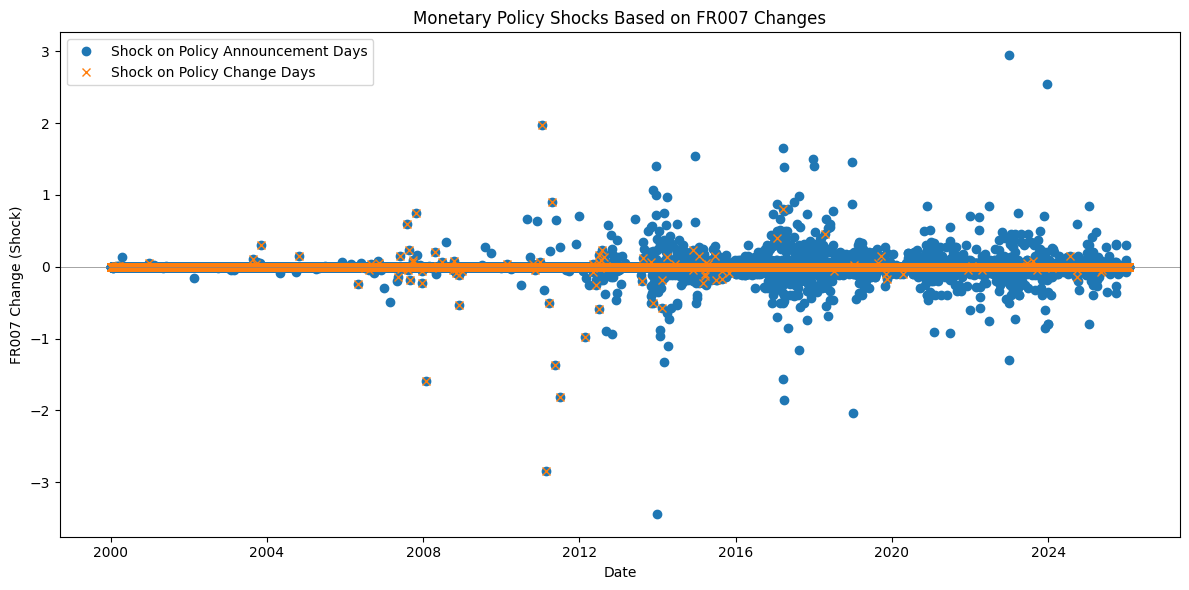

In [92]:
# fill missing shock_policy and shock_policy_change with 0 (no shock on non-policy days)
shock_df["shock_policy"] = shock_df["shock_policy"].fillna(0)
shock_df["shock_policy_change"] = shock_df["shock_policy_change"].fillna(0)
# plot the shocks over time
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(shock_df["date"], shock_df["shock_policy"], label="Shock on Policy Announcement Days", marker="o", linestyle="")
ax.plot(shock_df["date"], shock_df["shock_policy_change"], label="Shock on Policy Change Days", marker="x", linestyle="")
ax.axhline(0, color="grey", linewidth=0.5)
ax.set_xlabel("Date")
ax.set_ylabel("FR007 Change (Shock)")
ax.set_title("Monetary Policy Shocks Based on FR007 Changes")
ax.legend()
plt.tight_layout()
plt.show()   

In [93]:
# Group by month using sum to get total shock magnitude per month
hfi_core_shocks_df = shock_df[["date", "shock_policy", "shock_policy_change"]].copy()
# group by month and sum shocks
hfi_core_shocks_df = (
    hfi_core_shocks_df.groupby(hfi_core_shocks_df["date"].dt.to_period("M"))
    .agg({"shock_policy": "sum", "shock_policy_change": "sum"})
    .reset_index()
)
hfi_core_shocks_df["date"] = hfi_core_shocks_df["date"].dt.to_timestamp()


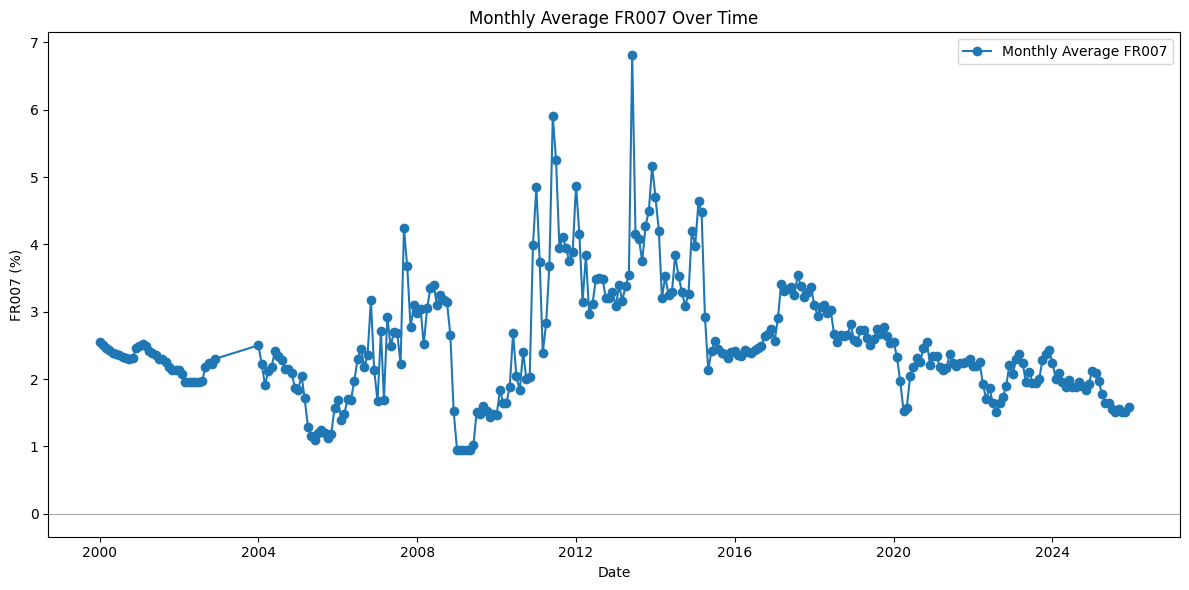

In [94]:
# just plot fr007 from full_repo_df 
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(full_repo_df["date"], full_repo_df["FR007"], label="Monthly Average FR007", marker="o")
ax.axhline(0, color="grey", linewidth=0.5)
ax.set_xlabel("Date")
ax.set_ylabel("FR007 (%)")
ax.set_title("Monthly Average FR007 Over Time")
ax.legend()
plt.tight_layout()
plt.show()


## Merge with previous data for IRFs

In [97]:
# merge hfi_core_shocks_df with romer_df on date and also IP_yoy from ip_df
hfi_core_csv_df = romer_df.merge(hfi_core_shocks_df, on="date", how="left")

In [98]:
# save to CSV for use in the dashboard
hfi_core_csv_df.to_csv("hfi_core_data.csv", index=False)

## Economic Data Calendar

from pathlib import Path
import warnings

cal_dir = Path("经济日历")

frames = []
for f in sorted(cal_dir.glob("*.xlsx")):
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        df = pd.read_excel(f, header=0, dtype=str)
    # drop footer rows (e.g. "数据来源: Wind") and fully empty rows
    df = df[~df["日期"].str.startswith("数据来源", na=True)]
    df = df.dropna(subset=["日期"])
    frames.append(df)

calendar_df = pd.concat(frames, ignore_index=True)

# parse date and numeric columns
calendar_df["日期"] = pd.to_datetime(calendar_df["日期"], errors="coerce")
for col in ["前值", "预测值", "今值"]:
    calendar_df[col] = pd.to_numeric(calendar_df[col], errors="coerce")

calendar_df = calendar_df.dropna(subset=["日期"]).sort_values("日期").reset_index(drop=True)

# keep only China entries, then drop the region column
calendar_df = calendar_df[calendar_df["国家/地区"] == "中国"].drop(columns=["国家/地区", "重要性", "时间"])

# rename and parse
calendar_df = calendar_df.rename(columns={
    "日期":  "date",
    "指标名称": "index",
    "前值":  "previous value",
    "预测值": "expectation",
    "今值":  "current value",
})

calendar_df["date"] = pd.to_datetime(calendar_df["date"], errors="coerce")
for col in ["previous value", "expectation", "current value"]:
    calendar_df[col] = pd.to_numeric(calendar_df[col], errors="coerce")

calendar_df["release"] = calendar_df["current value"].notna().astype(int)

# combine release into hfi_df
# Collapse calendar_df to one row per date: 1 if any indicator was released that day
daily_release = (
    calendar_df.groupby("date")["release"]
    .max()
    .reset_index()
)

hfi_df = hfi_df.merge(daily_release, on="date", how="left")
hfi_df["release"] = hfi_df["release"].fillna(0).astype(int)

# Joint dummy: policy action AND data release on the same day
hfi_df["policy_on_release"] = ((hfi_df["any_policy"] == 1) & (hfi_df["release"] == 1)).astype(int)

# combine release info with hfi_core_df
hfi_core_df = hfi_core_df.merge(daily_release, on="date", how="left")


hfi_core_df["release"] = hfi_core_df["release"].fillna(0).astype(int)

# Joint dummy: policy action AND data release on the same day
hfi_core_df["policy_on_release"] = ((hfi_core_df["any_policy"] == 1) & (hfi_core_df["release"] == 1)).astype(int)

# Collapse calendar_df to one row per date: 1 if any indicator was released that day
daily_release = (
    calendar_df.groupby("date")["release"]
    .max()
    .reset_index()
)

hfi_df = hfi_df.merge(daily_release, on="date", how="left")
hfi_df["release"] = hfi_df["release"].fillna(0).astype(int)

# Joint dummy: policy action AND data release on the same day
hfi_df["policy_on_release"] = ((hfi_df["any_policy"] == 1) & (hfi_df["release"] == 1)).astype(int)

print(hfi_df[["date", "any_policy", "release", "policy_on_release"]].tail(10).to_string())
print("\npolicy_on_release count:", hfi_df["policy_on_release"].sum())

# generate a dummay variable for each date if there is any announcement on that date
hfi_df["any_policy"] = (hfi_df[instrument_cols].any(axis=1)).astype(int)
